# K-Means on Full Data
**by Group 3**

## Installing and Importing Required Libraries

Install matplotlib for visualization

In [1]:
!pip install matplotlib

Java is installed for PySpark

In [2]:
!sudo yum install -y java-11-amazon-corretto-headless

Last metadata expiration check: 0:09:54 ago on Sun Jul 26 11:25:54 2026.
Package java-11-amazon-corretto-headless-1:11.0.31+11-1.amzn2023.x86_64 is already installed.
Dependencies resolved.
Nothing to do.
Complete!


In [3]:
import os
import glob

# Search for the installed Java directory
java_paths = glob.glob('/usr/lib/jvm/java-11*')

if java_paths:
    # Dynamically set the environment variable to the found path
    os.environ["JAVA_HOME"] = java_paths[0]
    print(f"JAVA_HOME successfully set to: {os.environ['JAVA_HOME']}")
else:
    print("Java not found. Did the yum install command work?")

JAVA_HOME successfully set to: /usr/lib/jvm/java-11-amazon-corretto.x86_64


Importing the necessary libraries for the model training

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

Setup a SparkSession

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark import StorageLevel
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

spark = (
    SparkSession.builder
    .appName("KMeans-Sample-Data")
    .master("local[*]")
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.aws.credentials.provider",
            "com.amazonaws.auth.InstanceProfileCredentialsProvider")
    .config("spark.driver.memory", "10g")
    .getOrCreate()
)

INPUT_PATH = "s3a://dat204m-project-g3/cleaned_data_final/"
OUTPUT_PATH = "s3a://dat204m-project-g3/sampled_eda_data/"


print("Spark ready:", spark.version)

:: loading settings :: url = jar:file:/home/ec2-user/anaconda3/envs/pytorch/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.0.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ec2-user/.ivy2/cache
The jars for the packages stored in: /home/ec2-user/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-7f727520-2876-402b-9d95-ba1f5f00c728;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 190ms :: artifacts dl 7ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|

26/07/26 11:36:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark ready: 3.3.0


Check if connection to s3 is stable

In [6]:
import boto3

s3 = boto3.client("s3")

try:
    print(s3.list_objects_v2(Bucket="dat204m-project-g3", MaxKeys=5))
except Exception as e:
    print(e)

{'ResponseMetadata': {'RequestId': 'YBS2TX2MQANYA7DQ', 'HostId': 'NdnF0Xtq8sGf4ONkvb5IImTHatUpgeps+CENBsExkfA2thOzKA5VdfgpUnzwWeL3pHpC4QMvqtM=', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amz-id-2': 'NdnF0Xtq8sGf4ONkvb5IImTHatUpgeps+CENBsExkfA2thOzKA5VdfgpUnzwWeL3pHpC4QMvqtM=', 'x-amz-request-id': 'YBS2TX2MQANYA7DQ', 'date': 'Sun, 26 Jul 2026 11:36:04 GMT', 'x-amz-bucket-region': 'us-east-1', 'content-type': 'application/xml', 'transfer-encoding': 'chunked', 'server': 'AmazonS3'}, 'RetryAttempts': 0}, 'IsTruncated': True, 'Contents': [{'Key': 'athena-logs/Unsaved/2026/07/05/0948405c-ddc7-4308-a5ea-9e4150ecd730-manifest.csv', 'LastModified': datetime.datetime(2026, 7, 4, 16, 28, 45, tzinfo=tzlocal()), 'ETag': '"c90c48a2b97547599fca337a336b68a1"', 'ChecksumAlgorithm': ['SHA1'], 'ChecksumType': 'FULL_OBJECT', 'Size': 3240, 'StorageClass': 'STANDARD'}, {'Key': 'athena-logs/Unsaved/2026/07/05/0948405c-ddc7-4308-a5ea-9e4150ecd730.metadata', 'LastModified': datetime.datetime(2026, 7, 4, 16, 28

## Reading and Standardizing Full Data

Read the Parquet file of the feature engineered full data

In [7]:
EDA_DATA_PATH = "s3a://dat204m-project-g3/feature_engineered_full/"
features_df = spark.read.parquet(EDA_DATA_PATH)

26/07/26 11:36:04 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Show the schema of the full data

In [8]:
features_df.printSchema()

root
 |-- product_id: string (nullable = true)
 |-- views: long (nullable = true)
 |-- likes: long (nullable = true)
 |-- cart: long (nullable = true)
 |-- offers: long (nullable = true)
 |-- buy_start: long (nullable = true)
 |-- buy_comp: long (nullable = true)
 |-- unique_users: long (nullable = true)
 |-- unique_sessions: long (nullable = true)
 |-- avg_price: double (nullable = true)
 |-- brand_name: string (nullable = true)
 |-- category_path: string (nullable = true)
 |-- cond_good: long (nullable = true)
 |-- cond_new: long (nullable = true)
 |-- cond_like_new: long (nullable = true)
 |-- cond_fair: long (nullable = true)
 |-- cond_poor: long (nullable = true)
 |-- cond_unknown: long (nullable = true)
 |-- log_views: double (nullable = true)
 |-- log_likes: double (nullable = true)
 |-- log_cart: double (nullable = true)
 |-- log_offers: double (nullable = true)
 |-- log_buy_start: double (nullable = true)
 |-- log_buy_comp: double (nullable = true)
 |-- log_users: double (null

Show the first five lines of the full data

In [9]:
features_df.show(5)

26/07/26 11:36:09 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


[Stage 1:>                                                          (0 + 1) / 1]

+----------+-----+-----+----+------+---------+--------+------------+---------------+------------------+--------------------+--------------------+---------+--------+-------------+---------+---------+------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+-----------------+------------------+----------------+
|product_id|views|likes|cart|offers|buy_start|buy_comp|unique_users|unique_sessions|         avg_price|          brand_name|       category_path|cond_good|cond_new|cond_like_new|cond_fair|cond_poor|cond_unknown|         log_views|         log_likes|          log_cart|        log_offers|     log_buy_start|      log_buy_comp|         log_users|      log_sessions|         log_price|     log_cond_good|     log_cond_new|log_cond_like_new|    log_cond_fair|     log_cond_poor|log_cond_unknown|
+----------+----

To reduce recomputation and improve performance, DataFrame is cached in memory and spills excess data to disk when needed

In [10]:
features_df = features_df.persist(StorageLevel.MEMORY_AND_DISK)

In [11]:
# Materialize cache
features_df.count()

1383996

Frequency Encoding is applied for categorical columns 'brand_name' and 'category_path' 

In [12]:
freq_cols = [
    "brand_name",
    "category_path"
]

features_encoded = features_df

for c in freq_cols:
    freq = (
        features_df.groupBy(c)
                   .count()
                   .withColumnRenamed("count", f"{c}_freq")
    )

    features_encoded = (
        features_encoded
        .join(freq, on=c, how="left")
    )

All numerical columns are combined into one single feature vector using VectorAssembler

In [13]:
numeric_features = [
    "log_views",
    "log_likes",
    "log_cart",
    "log_offers",
    "log_buy_comp",
    "log_buy_start",
    "log_users",
    "log_sessions",
    "log_price",
    "brand_name_freq",
    "category_path_freq",
    "log_cond_good",
    "log_cond_new",
    "log_cond_like_new",
    "log_cond_fair",
    "log_cond_poor",
    "log_cond_unknown"
]

assembler = VectorAssembler(
    inputCols=numeric_features,
    outputCol="features_raw"
)

Standard scaling is applied to prevent features with larger numerical ranges from dominating the clustering process

In [14]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

Pipeline is run to apply the vectorizing and standard scaling to the full data

In [15]:
pipeline = Pipeline(stages=[
    assembler,
    scaler
])

In [16]:
pipeline_model = pipeline.fit(features_encoded)

In [17]:
kmeans_df = pipeline_model.transform(features_encoded)

## Initial Model Training

As we do not have any target data, we will be doing unsupervised modelling with KMeans

Initialize a KMeans model

In [18]:
kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=10,
    seed=42
)

Fit the model to the data

In [19]:
model = kmeans.fit(kmeans_df)

Assign each product to its predicted cluster

In [20]:
clustered_products = model.transform(kmeans_df)

Evaluation Metrics used for KMeans are the following:

* Silhouette Score - Evaluates the similarity of an object to its own group relative to other groups, thereby reflecting the balance between cohesion and separation
* Davies-Bouldin Index - Quantifies group compactness and separation. A lower index signifies higher-quality clusters.
* Calinski–Harabasz Index - Used to compare different clustering results and help select the optimal number of clusters. A higher score indicates better-defined clusters with greater separation between clusters and higher compactness within clusters.

Based on Alshrouf, F., Masadeh, S., Al-Fraihat, D., & Al-Nsoor, R. (2025). Improving BIRCH hierarchical clustering algorithms for enhanced partitioning of medical data. Cluster Computing, 28(9), 600.

In [21]:
pdf = clustered_products.select("features", "cluster").toPandas()

X = np.vstack(pdf["features"].apply(lambda x: x.toArray()))
labels = pdf["cluster"].values

silhouette = silhouette_score(
    X,
    labels,
    sample_size=20000,
    random_state=42
)

dbi = davies_bouldin_score(X, labels)
chi = calinski_harabasz_score(X, labels)

print(f"Silhouette Score:        {silhouette:.4f}")
print(f"Davies-Bouldin Index:   {dbi:.4f}")
print(f"Calinski-Harabasz Index:{chi:.4f}")

Silhouette Score:        0.1836
Davies-Bouldin Index:   1.4341
Calinski-Harabasz Index:323824.8519


## Hyperparameter Tuning

We check which available hyperparameters can be changed

In [22]:
kmeans = KMeans()

print(kmeans.explainParams())

distanceMeasure: the distance measure. Supported options: 'euclidean' and 'cosine'. (default: euclidean)
featuresCol: features column name. (default: features)
initMode: The initialization algorithm. This can be either "random" to choose random points as initial cluster centers, or "k-means||" to use a parallel variant of k-means++ (default: k-means||)
initSteps: The number of steps for k-means|| initialization mode. Must be > 0. (default: 2)
k: The number of clusters to create. Must be > 1. (default: 2)
maxIter: max number of iterations (>= 0). (default: 20)
predictionCol: prediction column name. (default: prediction)
seed: random seed. (default: 4226294873962467018)
tol: the convergence tolerance for iterative algorithms (>= 0). (default: 0.0001)
weightCol: weight column name. If this is not set or empty, we treat all instance weights as 1.0. (undefined)


The selected hyperparameters to change are:
* K
* maxIter
* initMode
* initSteps

Based on Gikera, R., Mwaura, J., Muuro, E., & Mambo, S. K-Hyperparameter Tuning in High-Dimensional Space Clustering: Solving Smooth Elbow Challenges Using an Ensemble Based Technique of a Self-Adapting Autoencoder and Internal Validation Indexes.

In [23]:
# Hyperparameter values
k_values = [5, 8, 10, 12, 15]
maxIter_values = [20, 50]
initMode_values = ["k-means||", "random"]
initSteps_values = [2, 5, 10]

Silhouette evaluator from PySpark is used as evaluator for Hyperparameter tuning as it has efficient evaluation directly on Spark DataFrames without collecting large datasets into driver memory

In [24]:
evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

For every iteration, we will:

1. Set the KMeans model parameters using the current hyperparameter combination
2. Train the model to the dataset
3. Generate cluster predictions
4. Evaluate the model using the Silhouette Score
5. Record the hyperparameter combination and evaluation result
6. Keep track of the best-performing model and its corresponding hyperparameters based on the highest Silhouette Score

In [25]:
results = []
best_score = -1
best_model = None
best_params = None

for k in k_values:
    for maxIter in maxIter_values:
        for initMode in initMode_values:
            for initSteps in initSteps_values:

                kmeans = KMeans(
                    featuresCol="features",
                    predictionCol="cluster",
                    k=k,
                    maxIter=maxIter,
                    initMode=initMode,
                    initSteps=initSteps,
                    seed=42
                )

                model = kmeans.fit(kmeans_df)

                predictions = model.transform(kmeans_df)

                silhouette = evaluator.evaluate(predictions)

                results.append({
                    "k": k,
                    "maxIter": maxIter,
                    "initMode": initMode,
                    "initSteps": initSteps,
                    "silhouette": silhouette
                })

                print(
                    f"k={k:2d}, "
                    f"maxIter={maxIter:3d}, "
                    f"initMode={initMode:10s}, "
                    f"initSteps={initSteps:2d}, "
                    f"Silhouette={silhouette:.4f}"
                )

                if silhouette > best_score:
                    best_score = silhouette
                    best_model = model
                    best_params = {
                        "k": k,
                        "maxIter": maxIter,
                        "initMode": initMode,
                        "initSteps": initSteps
                    }

print("\nBest Hyperparameters")
print(best_params)
print(f"Best Silhouette Score: {best_score:.4f}")

k= 5, maxIter= 20, initMode=k-means|| , initSteps= 2, Silhouette=0.3265


k= 5, maxIter= 20, initMode=k-means|| , initSteps= 5, Silhouette=0.4007


k= 5, maxIter= 20, initMode=k-means|| , initSteps=10, Silhouette=0.2728


k= 5, maxIter= 20, initMode=random    , initSteps= 2, Silhouette=0.2710


k= 5, maxIter= 20, initMode=random    , initSteps= 5, Silhouette=0.2710


...

k=15, maxIter= 50, initMode=k-means|| , initSteps=10, Silhouette=0.2181


k=15, maxIter= 50, initMode=random    , initSteps= 2, Silhouette=0.2358


k=15, maxIter= 50, initMode=random    , initSteps= 5, Silhouette=0.2358


[Stage 9876:============================>                           (4 + 4) / 8]

k=15, maxIter= 50, initMode=random    , initSteps=10, Silhouette=0.2358

Best Hyperparameters
{'k': 5, 'maxIter': 50, 'initMode': 'k-means||', 'initSteps': 5}
Best Silhouette Score: 0.4066


## Train the Final Model

The best parameter is

{'k': 5, 'maxIter': 50, 'initMode': 'k-means||', 'initSteps': 5}

Train the final model with the best parameter

In [26]:
final_kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    **best_params
)

In [27]:
final_model = final_kmeans.fit(kmeans_df)

In [28]:
clustered_products = final_model.transform(kmeans_df)

Using Sklearn's Silhouette Score, Davies-Bouldin Index (DBI), Calinski-Harabasz Index (CHI), evaluate the model

Silhouette Score used a 20,000-sample subset to reduce computation from pairwise distance calculations while maintaining a reliable estimate. DBI and CHI were calculated on the full dataset due to their lower computational cost.

In [29]:
pdf = clustered_products.select("features", "cluster").toPandas()

X = np.vstack(pdf["features"].apply(lambda x: x.toArray()))
labels = pdf["cluster"].values

silhouette = silhouette_score(
    X,
    labels,
    sample_size=20000,
    random_state=42
)

dbi = davies_bouldin_score(X, labels)
chi = calinski_harabasz_score(X, labels)

print(f"Silhouette Score:       {silhouette:.4f}")
print(f"Davies-Bouldin Index:   {dbi:.4f}")
print(f"Calinski-Harabasz Index:{chi:.4f}")

Silhouette Score:       0.2628
Davies-Bouldin Index:   1.4659
Calinski-Harabasz Index:450109.3880


Check the rate for each condition in the clusters

In [30]:
clustered_products = clustered_products.withColumn(
    "total_conditions",
    F.col("cond_good") +
    F.col("cond_new") +
    F.col("cond_like_new") +
    F.col("cond_fair") +
    F.col("cond_poor") +
    F.col("cond_unknown")
)

In [31]:
clustered_products = (
    clustered_products
    .withColumn(
        "new_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_new") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "like_new_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_like_new") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "good_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_good") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "fair_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_fair") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "poor_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_poor") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "unknown_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_unknown") / F.col("total_conditions")
        ).otherwise(0)
    )
)

Check the summary per each cluster

In [32]:
cluster_summary = (
    clustered_products
    .groupBy("cluster")
    .agg(
        # Cluster size
        F.count("*").alias("num_products"),

        # Customer engagement
        F.round(F.avg("views"), 2).alias("avg_views"),
        F.round(F.avg("likes"), 2).alias("avg_likes"),
        F.round(F.avg("cart"), 2).alias("avg_cart"),
        F.round(F.avg("buy_comp"), 2).alias("avg_purchases"),

        # Customer reach
        F.round(F.avg("unique_users"), 2).alias("avg_unique_users"),
        F.round(F.avg("unique_sessions"), 2).alias("avg_unique_sessions"),

        # Product characteristics
        F.round(F.avg("avg_price"), 2).alias("avg_price"),

        # Condition profile
        F.round(F.avg("new_rate"), 3).alias("pct_new"),
        F.round(F.avg("like_new_rate"), 3).alias("pct_like_new"),
        F.round(F.avg("good_rate"), 3).alias("pct_good"),
        F.round(F.avg("fair_rate"), 3).alias("pct_fair"),
        F.round(F.avg("poor_rate"), 3).alias("pct_poor"),
        F.round(F.avg("unknown_rate"), 3).alias("pct_unknown")
    )
    .orderBy("cluster")
)

cluster_summary.show(truncate=False)

[Stage 10093:===========================>                           (4 + 4) / 8]

+-------+------------+---------+---------+--------+-------------+----------------+-------------------+---------+-------+------------+--------+--------+--------+-----------+
|cluster|num_products|avg_views|avg_likes|avg_cart|avg_purchases|avg_unique_users|avg_unique_sessions|avg_price|pct_new|pct_like_new|pct_good|pct_fair|pct_poor|pct_unknown|
+-------+------------+---------+---------+--------+-------------+----------------+-------------------+---------+-------+------------+--------+--------+--------+-----------+
|0      |762157      |7.62     |0.68     |0.06    |0.01         |6.51            |7.45               |36.23    |0.352  |0.254       |0.367   |0.024   |0.003   |0.0        |
|1      |68856       |63.48    |7.91     |0.78    |0.06         |50.08           |61.1               |35.1     |0.491  |0.195       |0.286   |0.024   |0.003   |0.0        |
|2      |411488      |91.84    |10.06    |0.91    |0.06         |68.52           |87.51              |58.31    |0.332  |0.261       |0.

## Supporting Visualizations

Visualize the Average Views, Average Likes, Average Cart, Average Purchases per Cluster

In [33]:
cluster_summary_pdf = cluster_summary.toPandas()

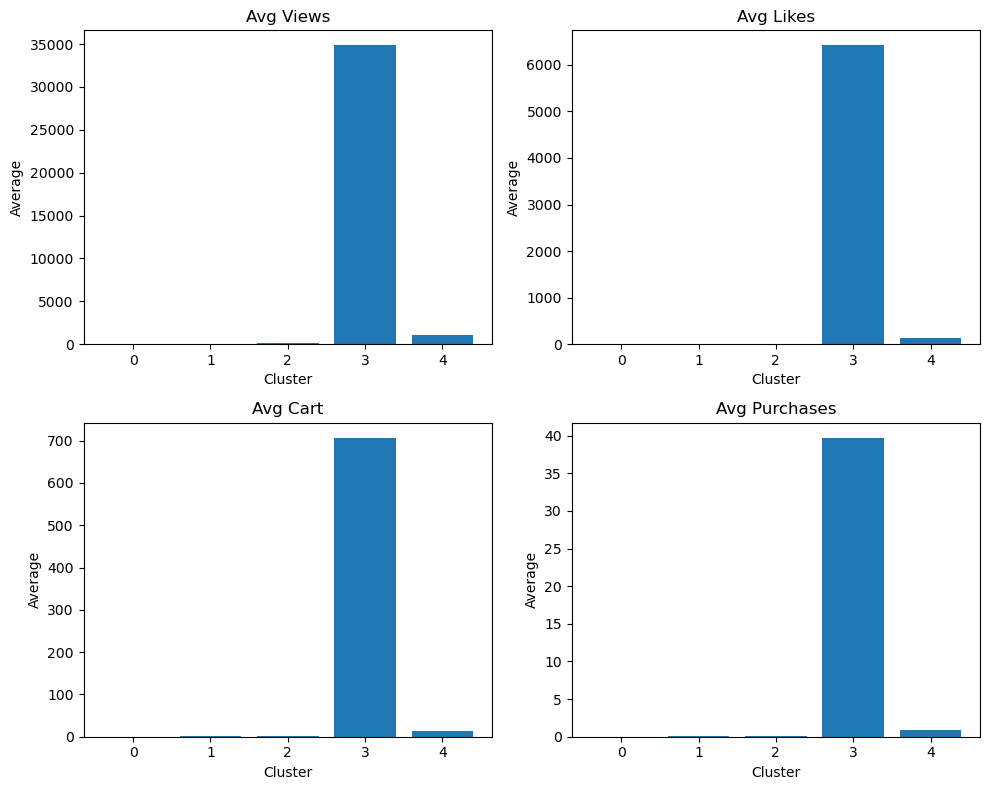

In [34]:
features = ["avg_views", "avg_likes", "avg_cart", "avg_purchases"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    ax.bar(cluster_summary_pdf["cluster"].astype(str), cluster_summary_pdf[feature])
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Average")

plt.tight_layout()
plt.show()

A normalized heatmap was generated to visualize and compare the relative feature profiles of each cluster, highlighting differences in customer engagement, reach, and product characteristics.

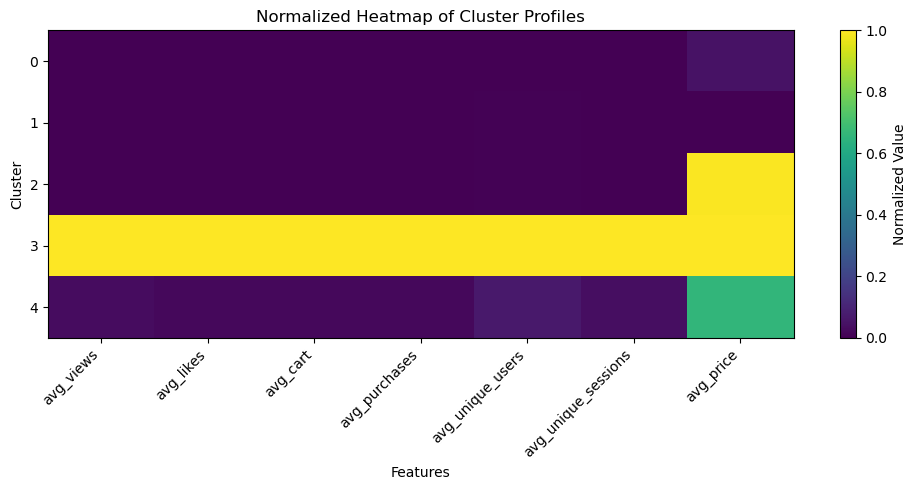

In [35]:
pdf = cluster_summary.select(
    "cluster",
    "avg_views",
    "avg_likes",
    "avg_cart",
    "avg_purchases",
    "avg_unique_users",
    "avg_unique_sessions",
    "avg_price"
).toPandas().sort_values("cluster")

data = pdf.set_index("cluster")

# Normalize each feature to [0, 1]
scaler = MinMaxScaler()
normalized = scaler.fit_transform(data)

plt.figure(figsize=(10, 5))

plt.imshow(normalized, aspect="auto")

plt.colorbar(label="Normalized Value")

plt.xticks(
    range(len(data.columns)),
    data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(data.index)),
    data.index
)

plt.xlabel("Features")
plt.ylabel("Cluster")
plt.title("Normalized Heatmap of Cluster Profiles")

plt.tight_layout()
plt.show()

PCA was used to project the clustered data into two dimensions for visualization of the cluster distribution and separation.

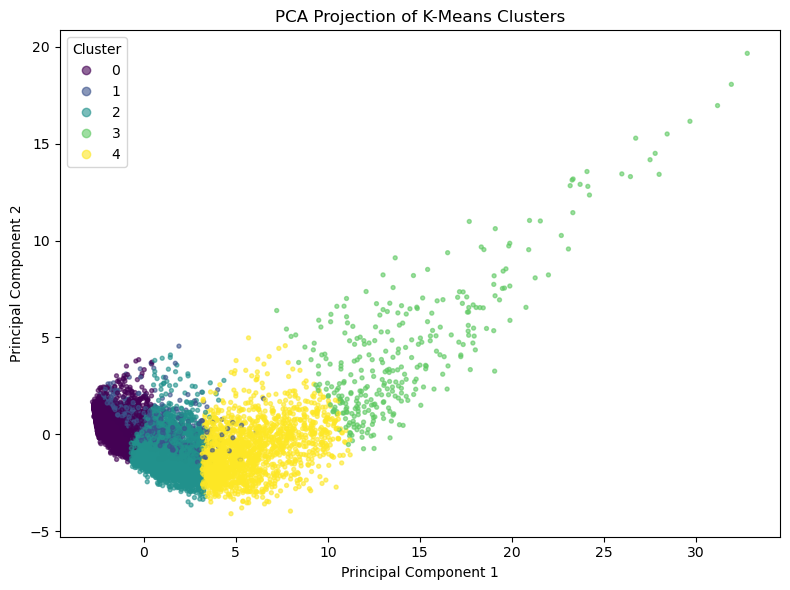

In [36]:
# Randomly sample 20,000 points
sample_size = 20000
idx = np.random.RandomState(42).choice(
    len(X),
    size=min(sample_size, len(X)),
    replace=False
)

X_sample = X[idx]
labels_sample = labels[idx]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_sample,
    s=8,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of K-Means Clusters")

plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()